<a href="https://colab.research.google.com/github/lunecarvalho/newslens-project/blob/main/05_training_testing_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd

df = pd.read_csv("dataset_preprocessado.csv")

In [47]:
df.shape

(7199, 11)

In [48]:
df.columns.tolist()

['id',
 'label',
 'arquivo',
 'texto_original',
 'texto_preprocessado',
 'topico_bertopic',
 'tema',
 'tamanho_caracteres',
 'tamanho_palavras',
 'texto_preprocessado_sem_acento',
 'texto_lematizado']

In [49]:
df["label"].value_counts()

,count
label,
falso,3600
verdadeiro,3599


Primeiro treinamento:

In [50]:
X = df["texto_preprocessado_sem_acento"].fillna("")
y = df["label"]

In [51]:
y = y.map({
    "falso": 0,
    "verdadeiro": 1
})

Reserva 20% dos dados para teste:

In [52]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_treino_tfidf = vectorizer.fit_transform(X_treino)
X_teste_tfidf = vectorizer.transform(X_teste)

In [54]:
print("Treino:", X_treino_tfidf.shape)
print("Teste:", X_teste_tfidf.shape)
print("Quantidade de termos:", len(vectorizer.get_feature_names_out()))

Treino: (5759, 113335)
Teste: (1440, 113335)
Quantidade de termos: 113335


### Regressão Logística:

In [55]:
from sklearn.linear_model import LogisticRegression

modelo_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_baseline.fit(
    X_treino_tfidf,
    y_treino
)

LogisticRegression(max_iter=1000, random_state=42)

In [56]:
y_pred = modelo_baseline.predict(X_teste_tfidf)

y_prob = modelo_baseline.predict_proba(X_teste_tfidf)[:, 1]

Avaliação do modelo:

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_teste, y_pred))
print("Precision:", precision_score(y_teste, y_pred))
print("Recall:", recall_score(y_teste, y_pred))
print("F1-score:", f1_score(y_teste, y_pred))

print("\nRelatório de classificação:")
print(
    classification_report(
        y_teste,
        y_pred,
        target_names=["Falsa", "Verdadeira"]
    )
)

Accuracy: 0.90625
Precision: 0.9068150208623088
Recall: 0.9055555555555556
F1-score: 0.906184850590688

Relatório de classificação:
              precision    recall  f1-score   support

       Falsa       0.91      0.91      0.91       720
  Verdadeira       0.91      0.91      0.91       720

    accuracy                           0.91      1440
   macro avg       0.91      0.91      0.91      1440
weighted avg       0.91      0.91      0.91      1440



Resultado inicial:

| Métrica       |  Resultado |
| ------------- | ---------: |
| **Accuracy**  | **90,63%** |
| **Precision** | **90,68%** |
| **Recall**    | **90,56%** |
| **F1-score**  | **90,62%** |


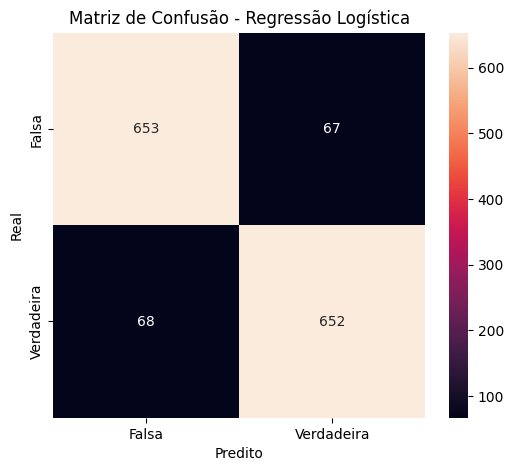

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

matriz = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    xticklabels=["Falsa", "Verdadeira"],
    yticklabels=["Falsa", "Verdadeira"]
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Regressão Logística")

plt.show()

Isso significa:

* **653 falsas** foram identificadas corretamente.
* **652 verdadeiras** foram identificadas corretamente.
* **67 falsas** foram classificadas como verdadeiras.
* **68 verdadeiras** foram classificadas como falsas.

Ou seja, o modelo errou 135 de 1.440 notícias.

### Treinamento Linear SVM:

In [59]:
from sklearn.svm import LinearSVC

modelo_svm = LinearSVC(
    random_state=42
)

modelo_svm.fit(
    X_treino_tfidf,
    y_treino
)

LinearSVC(random_state=42)

In [60]:
y_pred_svm = modelo_svm.predict(X_teste_tfidf)

In [61]:
print("Accuracy:", accuracy_score(y_teste, y_pred_svm))
print("Precision:", precision_score(y_teste, y_pred_svm))
print("Recall:", recall_score(y_teste, y_pred_svm))
print("F1-score:", f1_score(y_teste, y_pred_svm))

print("\nRelatório de classificação:")
print(
    classification_report(
        y_teste,
        y_pred_svm,
        target_names=["Falsa", "Verdadeira"]
    )
)

Accuracy: 0.9347222222222222
Precision: 0.929945054945055
Recall: 0.9402777777777778
F1-score: 0.9350828729281768

Relatório de classificação:
              precision    recall  f1-score   support

       Falsa       0.94      0.93      0.93       720
  Verdadeira       0.93      0.94      0.94       720

    accuracy                           0.93      1440
   macro avg       0.93      0.93      0.93      1440
weighted avg       0.93      0.93      0.93      1440



Usando o Linear SVM, o ganho de *Accuracy* foi de aproximadamente 2,84 pontos percentuais, e o *F1* aumentou de **90,62%** para **93,51%**.

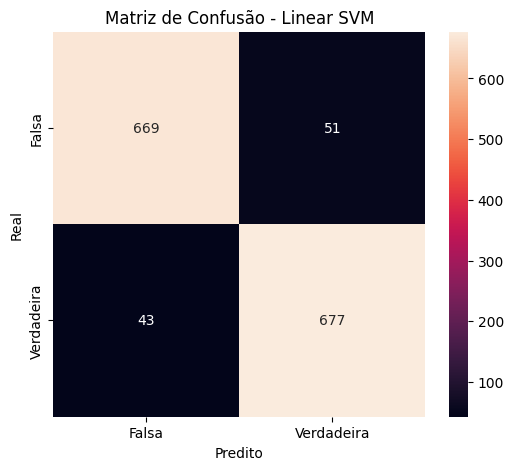

In [62]:
matriz_svm = confusion_matrix(y_teste, y_pred_svm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_svm,
    annot=True,
    fmt="d",
    xticklabels=["Falsa", "Verdadeira"],
    yticklabels=["Falsa", "Verdadeira"]
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Linear SVM")

plt.show()

Dos 1.440 textos de teste:

* **669 falsas** → corretamente
identificadas como falsas.
* **677 verdadeiras** → corretamente identificadas como verdadeiras.
* **51 falsas** → classificadas incorretamente como verdadeiras.
* **43 verdadeiras** → classificadas incorretamente como falsas.

Isso dá **1.346** acertos de **1.440**, ou **93,47%.**

### Naive Bayes:

In [63]:
from sklearn.naive_bayes import MultinomialNB

modelo_nb = MultinomialNB()

modelo_nb.fit(
    X_treino_tfidf,
    y_treino
)

MultinomialNB()

In [64]:
y_pred_nb = modelo_nb.predict(X_teste_tfidf)

In [65]:
print("Accuracy:", accuracy_score(y_teste, y_pred_nb))
print("Precision:", precision_score(y_teste, y_pred_nb))
print("Recall:", recall_score(y_teste, y_pred_nb))
print("F1-score:", f1_score(y_teste, y_pred_nb))

print("\nRelatório de classificação:")
print(
    classification_report(
        y_teste,
        y_pred_nb,
        target_names=["Falsa", "Verdadeira"]
    )
)

Accuracy: 0.8694444444444445
Precision: 0.8565683646112601
Recall: 0.8875
F1-score: 0.8717598908594816

Relatório de classificação:
              precision    recall  f1-score   support

       Falsa       0.88      0.85      0.87       720
  Verdadeira       0.86      0.89      0.87       720

    accuracy                           0.87      1440
   macro avg       0.87      0.87      0.87      1440
weighted avg       0.87      0.87      0.87      1440



*Naive Bayes* mostra **desempenho** **inferior** comparado a *Regressão Logística* e *Linear SVM*.

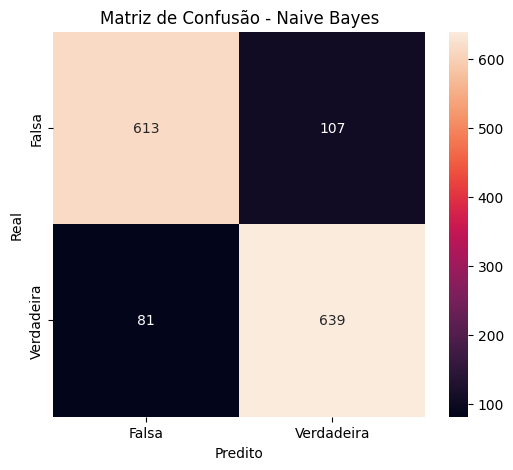

In [66]:
matriz_nb = confusion_matrix(y_teste, y_pred_nb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_nb,
    annot=True,
    fmt="d",
    xticklabels=["Falsa", "Verdadeira"],
    yticklabels=["Falsa", "Verdadeira"]
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Naive Bayes")

plt.show()

#### Comparação dos três modelos:

| Modelo              |   Accuracy |  Precision |     Recall |   F1-score |
| ------------------- | ---------: | ---------: | ---------: | ---------: |
| Regressão Logística |     90,63% |     90,68% |     90,56% |     90,62% |
| **Linear SVM**      | **93,47%** | **92,99%** | **94,03%** | **93,51%** |
| Naive Bayes         |     86,94% |     85,66% |     88,75% |     87,18% |

Para a representação textual atual baseada em **TF-IDF com unigramas + bigramas**, o *Linear SVM* foi o modelo que melhor conseguiu separar notícias falsas e verdadeiras.

In [67]:
resultados_modelos = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Linear SVM",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_teste, y_pred),
        accuracy_score(y_teste, y_pred_svm),
        accuracy_score(y_teste, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_teste, y_pred),
        precision_score(y_teste, y_pred_svm),
        precision_score(y_teste, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_teste, y_pred),
        recall_score(y_teste, y_pred_svm),
        recall_score(y_teste, y_pred_nb)
    ],
    "F1-score": [
        f1_score(y_teste, y_pred),
        f1_score(y_teste, y_pred_svm),
        f1_score(y_teste, y_pred_nb)
    ]
})

resultados_modelos

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regressão Logística,0.906250,0.906815,0.905556,0.906185
1,Linear SVM,0.934722,0.929945,0.940278,0.935083
2,Naive Bayes,0.869444,0.856568,0.887500,0.871760


#### Validação cruzada:

In [68]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

modelo_svm_cv = LinearSVC(random_state=42)

In [69]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [70]:
scores_svm = cross_val_score(
    modelo_svm_cv,
    X_treino_tfidf,
    y_treino,
    cv=cv,
    scoring="f1"
)

In [71]:
print("F1-score por fold:", scores_svm)
print("F1-score médio:", scores_svm.mean())
print("Desvio padrão:", scores_svm.std())

F1-score por fold: [0.91270527 0.93884582 0.93310165 0.93240901 0.93133803]
F1-score médio: 0.9296799571723611
Desvio padrão: 0.008877589128869082


In [72]:
from sklearn.model_selection import GridSearchCV

parametros_svm = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid_svm = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=parametros_svm,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_svm.fit(
    X_treino_tfidf,
    y_treino
)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LinearSVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100]}, return_train_score=True,
             scoring='f1')

In [73]:
print("Melhor valor de C:", grid_svm.best_params_)
print("Melhor F1 médio:", grid_svm.best_score_)

Melhor valor de C: {'C': 10}
Melhor F1 médio: 0.9298865490299475


In [74]:
resultados_grid = pd.DataFrame(
    grid_svm.cv_results_
)

resultados_grid[[
    "param_C",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

,param_C,mean_train_score,mean_test_score,std_test_score,rank_test_score
3,10.00,1.000000,0.929887,0.009075,1
2,1.00,1.000000,0.929680,0.008878,2
4,100.00,1.000000,0.929233,0.008691,3
1,0.10,0.982134,0.909580,0.010847,4
0,0.01,0.918720,0.861326,0.009266,5


#### Validação com conjunto de treino:

In [81]:
from sklearn.model_selection import GridSearchCV

parametros_svm = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid_svm = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=parametros_svm,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_svm.fit(
    X_treino_tfidf,
    y_treino
)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LinearSVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100]}, return_train_score=True,
             scoring='f1')

In [75]:
from sklearn.pipeline import Pipeline

pipeline_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("svm", LinearSVC(random_state=42))
])

In [76]:
scores_pipeline = cross_val_score(
    pipeline_svm,
    X_treino,
    y_treino,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("F1-score por fold:", scores_pipeline)
print("F1-score médio:", scores_pipeline.mean())
print("Desvio padrão:", scores_pipeline.std())

F1-score por fold: [0.91537133 0.94067068 0.93136403 0.93160173 0.92819615]
F1-score médio: 0.9294407838292094
Desvio padrão: 0.00817285486011413


In [77]:
parametros_pipeline = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],
    "tfidf__min_df": [
        2,
        3,
        5
    ],
    "svm__C": [
        0.1,
        1,
        10
    ]
}

In [82]:
grid_pipeline = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=parametros_pipeline,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_pipeline.fit(
    X_treino,
    y_treino
)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_df=0.95, min_df=2,
                                                        ngram_range=(1, 2),
                                                        sublinear_tf=True)),
                                       ('svm', LinearSVC(random_state=42))]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10], 'tfidf__min_df': [2, 3, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             return_train_score=True, scoring='f1')

In [83]:
print("Melhores parâmetros:")
print(grid_pipeline.best_params_)

print("\nMelhor F1 médio:")
print(grid_pipeline.best_score_)

Melhores parâmetros:
{'svm__C': 1, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}

Melhor F1 médio:
0.9306684962921243


In [84]:
resultados_grid_pipeline = pd.DataFrame(
    grid_pipeline.cv_results_
)

resultados_grid_pipeline[[
    "param_tfidf__ngram_range",
    "param_tfidf__min_df",
    "param_svm__C",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score").head(10)

,param_tfidf__ngram_range,param_tfidf__min_df,param_svm__C,mean_train_score,mean_test_score,std_test_score,rank_test_score
11,"(1, 2)",5,1.0,1.000000,0.930668,0.006596,1
9,"(1, 2)",3,1.0,1.000000,0.930345,0.010084,2
7,"(1, 2)",2,1.0,1.000000,0.929441,0.008173,3
13,"(1, 2)",2,10.0,1.000000,0.929370,0.009314,4
15,"(1, 2)",3,10.0,1.000000,0.926780,0.007663,5
17,"(1, 2)",5,10.0,1.000000,0.926342,0.005706,6
6,"(1, 1)",2,1.0,0.999957,0.920612,0.005509,7
8,"(1, 1)",3,1.0,0.999957,0.919661,0.005853,8
10,"(1, 1)",5,1.0,0.999826,0.918348,0.006646,9
5,"(1, 2)",5,0.1,0.976708,0.918095,0.010641,10


In [85]:
modelo_final_svm = grid_pipeline.best_estimator_

modelo_final_svm

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=5, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('svm', LinearSVC(C=1, random_state=42))])

In [86]:
y_pred_final_svm = modelo_final_svm.predict(X_teste)

In [87]:
print("Accuracy:", accuracy_score(y_teste, y_pred_final_svm))

print("\nRelatório de classificação:")
print(
    classification_report(
        y_teste,
        y_pred_final_svm,
        target_names=["Falsa", "Verdadeira"]
    )
)

print("\nMatriz de confusão:")
print(
    confusion_matrix(
        y_teste,
        y_pred_final_svm
    )
)

Accuracy: 0.9333333333333333

Relatório de classificação:
              precision    recall  f1-score   support

       Falsa       0.94      0.93      0.93       720
  Verdadeira       0.93      0.94      0.93       720

    accuracy                           0.93      1440
   macro avg       0.93      0.93      0.93      1440
weighted avg       0.93      0.93      0.93      1440


Matriz de confusão:
[[666  54]
 [ 42 678]]


A otimização dos hiperparâmetros por GridSearchCV resultou em pequena melhora do F1-score médio na validação cruzada, passando de aproximadamente 92,94% para 93,07%. Entretanto, no conjunto de teste, o modelo otimizado obteve acurácia de 93,33%, ligeiramente inferior aos 93,47% do SVM inicial. Dessa forma, os resultados indicam que a otimização não proporcionou ganho significativo de desempenho.

In [88]:
X_treino_lematizado = df.loc[X_treino.index, "texto_lematizado"].fillna("")
X_teste_lematizado = df.loc[X_teste.index, "texto_lematizado"].fillna("")

In [89]:
print("Treino:", X_treino_lematizado.shape)
print("Teste:", X_teste_lematizado.shape)

Treino: (5759,)
Teste: (1440,)


In [90]:
pipeline_svm_lematizado = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("svm", LinearSVC(
        C=1,
        random_state=42
    ))
])

In [91]:
scores_lematizado = cross_val_score(
    pipeline_svm_lematizado,
    X_treino_lematizado,
    y_treino,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("F1-score por fold:", scores_lematizado)
print("F1-score médio:", scores_lematizado.mean())
print("Desvio padrão:", scores_lematizado.std())

F1-score por fold: [0.91349481 0.92678725 0.921875   0.92640693 0.92994746]
F1-score médio: 0.9237022898119204
Desvio padrão: 0.005716044956575752


A aplicação da lematização foi avaliada como etapa adicional de pré-processamento. Utilizando o mesmo pipeline TF-IDF + Linear SVM, o texto lematizado apresentou F1-score médio de 92,37% na validação cruzada, enquanto a representação sem lematização alcançou 93,07%. Dessa forma, a lematização não apresentou ganho de desempenho.

### Análise de erros do SVM:

In [92]:
df_erros = df.loc[X_teste.index].copy()

df_erros["label_real"] = y_teste
df_erros["label_predito"] = y_pred_final_svm

In [93]:
mapa_labels = {
    0: "Falsa",
    1: "Verdadeira"
}

df_erros["classe_real"] = df_erros["label_real"].map(mapa_labels)
df_erros["classe_predita"] = df_erros["label_predito"].map(mapa_labels)

In [94]:
df_erros["resultado"] = (
    df_erros["label_real"] == df_erros["label_predito"]
).map({
    True: "Acerto",
    False: "Erro"
})

In [95]:
df_erros[[
    "classe_real",
    "classe_predita",
    "resultado"
]].head()

,classe_real,classe_predita,resultado
3060,Falsa,Falsa,Acerto
2027,Falsa,Falsa,Acerto
3106,Falsa,Falsa,Acerto
4024,Verdadeira,Verdadeira,Acerto
452,Falsa,Falsa,Acerto


In [96]:
df_erros["resultado"].value_counts()

,count
resultado,
Acerto,1344
Erro,96


In [97]:
erros_svm = df_erros[
    df_erros["resultado"] == "Erro"
].copy()

erros_svm.shape

(96, 16)

In [98]:
falsas_como_verdadeiras = erros_svm[
    (erros_svm["label_real"] == 0) &
    (erros_svm["label_predito"] == 1)
]

len(falsas_como_verdadeiras)

54

In [99]:
verdadeiras_como_falsas = erros_svm[
    (erros_svm["label_real"] == 1) &
    (erros_svm["label_predito"] == 0)
]

len(verdadeiras_como_falsas)

42

In [100]:
erros_por_tema = (
    erros_svm["tema"]
    .value_counts()
    .reset_index()
)

erros_por_tema.columns = [
    "tema",
    "quantidade_erros"
]

erros_por_tema

,tema,quantidade_erros
0,Política,35
1,Segurança,13
2,Economia,9
3,Corrupção,8
4,Internacional,5
5,Saúde,5
6,Tecnologia,4
7,Entretenimento,4
8,Sociedade,3
9,Meio Ambiente,3


#### Calcular a taxa de erro por tema:

In [101]:
total_por_tema = (
    df_erros["tema"]
    .value_counts()
    .reset_index()
)

total_por_tema.columns = [
    "tema",
    "total_teste"
]

total_por_tema

,tema,total_teste
0,Política,632
1,Segurança,149
2,Corrupção,110
3,Internacional,96
4,Economia,80
5,Entretenimento,64
6,Saúde,57
7,Cultura,39
8,Sociedade,35
9,Religião,32


In [102]:
analise_erros_tema = total_por_tema.merge(
    erros_por_tema,
    on="tema",
    how="left"
)

analise_erros_tema["quantidade_erros"] = (
    analise_erros_tema["quantidade_erros"]
    .fillna(0)
    .astype(int)
)

In [103]:
analise_erros_tema["taxa_erro"] = (
    analise_erros_tema["quantidade_erros"]
    / analise_erros_tema["total_teste"]
)

analise_erros_tema["taxa_erro_percentual"] = (
    analise_erros_tema["taxa_erro"] * 100
)

In [104]:
analise_erros_tema = analise_erros_tema.sort_values(
    "taxa_erro_percentual",
    ascending=False
)

analise_erros_tema[[
    "tema",
    "total_teste",
    "quantidade_erros",
    "taxa_erro_percentual"
]]

,tema,total_teste,quantidade_erros,taxa_erro_percentual
19,Transportes,4,1,25.000000
14,Tecnologia,18,4,22.222222
13,Meio Ambiente,18,3,16.666667
4,Economia,80,9,11.250000
17,Alimentação,9,1,11.111111
12,Acidentes,22,2,9.090909
6,Saúde,57,5,8.771930
1,Segurança,149,13,8.724832
8,Sociedade,35,3,8.571429
2,Corrupção,110,8,7.272727


In [105]:
def classificar_tipo_erro(linha):
    if linha["label_real"] == linha["label_predito"]:
        return "Acerto"

    if linha["label_real"] == 0 and linha["label_predito"] == 1:
        return "Falsa → Verdadeira"

    if linha["label_real"] == 1 and linha["label_predito"] == 0:
        return "Verdadeira → Falsa"

df_erros["tipo_erro"] = df_erros.apply(
    classificar_tipo_erro,
    axis=1
)

In [106]:
df_erros["tipo_erro"].value_counts()

,count
tipo_erro,
Acerto,1344
Falsa → Verdadeira,54
Verdadeira → Falsa,42


In [107]:
tipos_erro_tema = (
    df_erros[df_erros["tipo_erro"] != "Acerto"]
    .groupby(["tema", "tipo_erro"])
    .size()
    .unstack(fill_value=0)
)

In [108]:
tipos_erro_tema["Total"] = tipos_erro_tema.sum(axis=1)

tipos_erro_tema = tipos_erro_tema.sort_values(
    "Total",
    ascending=False
)

tipos_erro_tema

tipo_erro,Falsa → Verdadeira,Verdadeira → Falsa,Total
tema,,,
Política,19,16,35
Segurança,7,6,13
Economia,5,4,9
Corrupção,5,3,8
Internacional,3,2,5
Saúde,3,2,5
Tecnologia,2,2,4
Entretenimento,2,2,4
Sociedade,1,2,3


In [109]:
colunas_analise = [
    "tema",
    "classe_real",
    "classe_predita",
    "texto_original"
]

df_erros[
    df_erros["tipo_erro"] == "Falsa → Verdadeira"
][colunas_analise].head(10)

,tema,classe_real,classe_predita,texto_original
3456,Economia,Falsa,Verdadeira,Ex-petista diz que governos Lula/Dilma fizeram...
1495,Política,Falsa,Verdadeira,"Candidato que ""vomita quando vê pobres"" vence ..."
2235,Política,Falsa,Verdadeira,Justiça acaba de determinar o fim do Instituto...
1663,Religião,Falsa,Verdadeira,Suzane Richthofen quer virar pastora evangélic...
2869,Política,Falsa,Verdadeira,Lista dos 29 deputados da CCJ que votaram pelo...
703,Internacional,Falsa,Verdadeira,Terrorista tenta invadir a residência oficial ...
2904,Segurança,Falsa,Verdadeira,Temer reduz equipe da Lava Jato e corta verba ...
515,Internacional,Falsa,Verdadeira,Kim Jon-un envia carta para países asiáticos p...
1155,Transportes,Falsa,Verdadeira,Temer avisa que vai vetar a lei anti-Uber. Mes...
1153,Política,Falsa,Verdadeira,O partido mais corrupto do Brasil não é o PT. ...


In [110]:
df_erros[
    df_erros["tipo_erro"] == "Verdadeira → Falsa"
][colunas_analise].head(10)

,tema,classe_real,classe_predita,texto_original
5124,Corrupção,Verdadeira,Falsa,O operador de propinas Fernando Antonio Falcão...
6083,Economia,Verdadeira,Falsa,Por que milhares de pessoas receberão salários...
6441,Esportes,Verdadeira,Falsa,Andrés diz: 'Falar que o Corinthians está queb...
6124,Política,Verdadeira,Falsa,Frentes 'unem' Bolsonaro e Jean Wyllys Preside...
5064,Sociedade,Verdadeira,Falsa,Idoso morre após ser baleado durante briga em ...
6349,Economia,Verdadeira,Falsa,Vendo comparações entre as homenagens a Brilha...
6944,Tecnologia,Verdadeira,Falsa,"Nessa semana, fui apresentado a mais um sistem..."
4439,Corrupção,Verdadeira,Falsa,"Muito antes da Operação Lava Jato existir, em ..."
6630,Política,Verdadeira,Falsa,O argumento usado pelo ministro Lewandowski pa...
5978,Política,Verdadeira,Falsa,"Nos enche de vergonha, diz Gilmar Mendes. Mini..."


In [111]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_erros = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_erros_tfidf = vectorizer_erros.fit_transform(
    erros_svm["texto_preprocessado_sem_acento"].fillna("")
)

In [112]:
import numpy as np

termos_erros = np.array(
    vectorizer_erros.get_feature_names_out()
)

media_tfidf_erros = np.asarray(
    X_erros_tfidf.mean(axis=0)
).ravel()

indices = media_tfidf_erros.argsort()[-30:][::-1]

pd.DataFrame({
    "termo": termos_erros[indices],
    "tfidf_medio": media_tfidf_erros[indices]
})

,termo,tfidf_medio
0,que,0.107084
1,do,0.083452
2,da,0.076326
3,em,0.062554
4,para,0.051377
5,um,0.044748
6,uma,0.042103
7,no,0.041648
8,na,0.039542
9,se,0.038998


In [115]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stopwords_pt = set(stopwords.words("portuguese"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [117]:
import unicodedata

def remover_acentos(texto):
    return "".join(
        caractere
        for caractere in unicodedata.normalize("NFD", texto)
        if unicodedata.category(caractere) != "Mn"
    )

stopwords_pt = {
    remover_acentos(palavra)
    for palavra in stopwords.words("portuguese")
}

In [118]:
vectorizer_erros = TfidfVectorizer(
    stop_words=list(stopwords_pt),
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_erros_tfidf = vectorizer_erros.fit_transform(
    erros_svm["texto_preprocessado_sem_acento"].fillna("")
)

In [119]:
termos_erros = np.array(
    vectorizer_erros.get_feature_names_out()
)

media_tfidf_erros = np.asarray(
    X_erros_tfidf.mean(axis=0)
).ravel()

indices = media_tfidf_erros.argsort()[-30:][::-1]

top_termos_erros = pd.DataFrame({
    "termo": termos_erros[indices],
    "tfidf_medio": media_tfidf_erros[indices]
})

top_termos_erros

,termo,tfidf_medio
0,presidente,0.026619
1,federal,0.025164
2,disse,0.022877
3,policia,0.021733
4,ex,0.021327
5,brasil,0.021121
6,sobre,0.021117
7,apos,0.020874
8,anos,0.020843
9,pais,0.020398


In [120]:
erros_fv = df_erros[
    df_erros["tipo_erro"] == "Falsa → Verdadeira"
]

erros_vf = df_erros[
    df_erros["tipo_erro"] == "Verdadeira → Falsa"
]

In [121]:
def obter_top_termos(textos, stopwords_pt, n=30):
    vectorizer = TfidfVectorizer(
        stop_words=list(stopwords_pt),
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )

    matriz = vectorizer.fit_transform(
        textos.fillna("")
    )

    termos = np.array(
        vectorizer.get_feature_names_out()
    )

    media_tfidf = np.asarray(
        matriz.mean(axis=0)
    ).ravel()

    indices = media_tfidf.argsort()[-n:][::-1]

    return pd.DataFrame({
        "termo": termos[indices],
        "tfidf_medio": media_tfidf[indices]
    })

In [122]:
top_falsa_para_verdadeira = obter_top_termos(
    erros_fv["texto_preprocessado_sem_acento"],
    stopwords_pt
)

top_falsa_para_verdadeira

,termo,tfidf_medio
0,federal,0.033985
1,policia,0.031537
2,presidente,0.031043
3,brasil,0.029811
4,anos,0.026148
5,policia federal,0.025720
6,apos,0.024643
7,disse,0.024472
8,mil,0.023923
9,pessoas,0.023842


In [123]:
top_verdadeira_para_falsa = obter_top_termos(
    erros_vf["texto_preprocessado_sem_acento"],
    stopwords_pt
)

top_verdadeira_para_falsa

,termo,tfidf_medio
0,presidente,0.035868
1,sobre,0.033961
2,disse,0.032831
3,contra,0.031734
4,pode,0.030738
5,ex,0.030175
6,ter,0.029442
7,pais,0.028757
8,apos,0.027671
9,anos,0.027064


#### Confiança do SVM:

In [124]:
scores_svm = modelo_final_svm.decision_function(X_teste)

df_erros["score_svm"] = scores_svm
df_erros["margem_svm"] = abs(scores_svm)

In [125]:
erros_ordenados = (
    df_erros[df_erros["resultado"] == "Erro"]
    .sort_values("margem_svm")
)

erros_ordenados[
    [
        "tema",
        "classe_real",
        "classe_predita",
        "score_svm",
        "margem_svm",
        "texto_original"
    ]
].head(10)

,tema,classe_real,classe_predita,score_svm,margem_svm,texto_original
3877,Sociedade,Verdadeira,Falsa,-0.001787,0.001787,"Para proteger avó, adolescente atira e mata o ..."
3184,Corrupção,Falsa,Verdadeira,0.006058,0.006058,Operação Zelotes indicia presidente do Bradesc...
3108,Meio Ambiente,Falsa,Verdadeira,0.006501,0.006501,Mais um crime! Vale do Rio Doce entregou água ...
1369,Corrupção,Falsa,Verdadeira,0.008208,0.008208,Os principais beneficiários de repasses da Ode...
1649,Política,Falsa,Verdadeira,0.024342,0.024342,Empresários que fizeram doações para SP elogia...
4698,Política,Verdadeira,Falsa,-0.025309,0.025309,Juízes e promotores de Piracicaba fazem manife...
515,Internacional,Falsa,Verdadeira,0.025459,0.025459,Kim Jon-un envia carta para países asiáticos p...
3362,Acidentes,Falsa,Verdadeira,0.026857,0.026857,"Taxista confunde viatura com Uber, ataca o car..."
3456,Economia,Falsa,Verdadeira,0.027139,0.027139,Ex-petista diz que governos Lula/Dilma fizeram...
3704,Economia,Verdadeira,Falsa,-0.034440,0.034440,Trabalho forçado pode impactar exportações bra...


In [126]:
erros_ordenados["margem_svm"].describe()

,margem_svm
count,96.000000
mean,0.246694
std,0.200100
min,0.001787
25%,0.091270
50%,0.185938
75%,0.369606
max,0.751268


In [127]:
def classificar_margem(margem):
    if margem < 0.10:
        return "Próximo da fronteira"
    elif margem < 0.40:
        return "Intermediário"
    else:
        return "Distante da fronteira"

df_erros["faixa_margem"] = df_erros["margem_svm"].apply(classificar_margem)

df_erros[
    df_erros["resultado"] == "Erro"
]["faixa_margem"].value_counts()

,count
faixa_margem,
Intermediário,47
Próximo da fronteira,27
Distante da fronteira,22


In [128]:
erros_confiantes = (
    df_erros[df_erros["resultado"] == "Erro"]
    .sort_values("margem_svm", ascending=False)
)

erros_confiantes[
    [
        "tema",
        "tipo_erro",
        "score_svm",
        "margem_svm",
        "texto_original"
    ]
].head(10)

,tema,tipo_erro,score_svm,margem_svm,texto_original
1147,Saúde,Falsa → Verdadeira,0.751268,0.751268,Joesley chorou ao entrar na cela e está sem co...
2904,Segurança,Falsa → Verdadeira,0.708285,0.708285,Temer reduz equipe da Lava Jato e corta verba ...
143,Saúde,Falsa → Verdadeira,0.704578,0.704578,Colômbia vive surto de zika. Mais de 22 mil ca...
2235,Política,Falsa → Verdadeira,0.641262,0.641262,Justiça acaba de determinar o fim do Instituto...
3330,Segurança,Falsa → Verdadeira,0.631865,0.631865,Delação da Odebrecht pode colocar Aécio no cam...
2160,Segurança,Falsa → Verdadeira,0.598337,0.598337,Executivo alvo da operação Acarajé é preso em ...
225,Tecnologia,Falsa → Verdadeira,0.595094,0.595094,Anatel afirma que tem Prioridade para a univer...
6069,Segurança,Verdadeira → Falsa,-0.584795,0.584795,O esforço da defesa do ex-presidente Lula para...
1081,Política,Falsa → Verdadeira,0.582888,0.582888,URGENTE – Moro acaba de condenar Lula. Primeir...
1155,Transportes,Falsa → Verdadeira,0.570828,0.570828,Temer avisa que vai vetar a lei anti-Uber. Mes...


In [129]:
erros_distantes = (
    df_erros[
        (df_erros["resultado"] == "Erro") &
        (df_erros["faixa_margem"] == "Distante da fronteira")
    ]
    .sort_values("margem_svm", ascending=False)
)

erros_distantes[
    [
        "tema",
        "tipo_erro",
        "score_svm",
        "margem_svm",
        "texto_original"
    ]
].head(10)

,tema,tipo_erro,score_svm,margem_svm,texto_original
1147,Saúde,Falsa → Verdadeira,0.751268,0.751268,Joesley chorou ao entrar na cela e está sem co...
2904,Segurança,Falsa → Verdadeira,0.708285,0.708285,Temer reduz equipe da Lava Jato e corta verba ...
143,Saúde,Falsa → Verdadeira,0.704578,0.704578,Colômbia vive surto de zika. Mais de 22 mil ca...
2235,Política,Falsa → Verdadeira,0.641262,0.641262,Justiça acaba de determinar o fim do Instituto...
3330,Segurança,Falsa → Verdadeira,0.631865,0.631865,Delação da Odebrecht pode colocar Aécio no cam...
2160,Segurança,Falsa → Verdadeira,0.598337,0.598337,Executivo alvo da operação Acarajé é preso em ...
225,Tecnologia,Falsa → Verdadeira,0.595094,0.595094,Anatel afirma que tem Prioridade para a univer...
6069,Segurança,Verdadeira → Falsa,-0.584795,0.584795,O esforço da defesa do ex-presidente Lula para...
1081,Política,Falsa → Verdadeira,0.582888,0.582888,URGENTE – Moro acaba de condenar Lula. Primeir...
1155,Transportes,Falsa → Verdadeira,0.570828,0.570828,Temer avisa que vai vetar a lei anti-Uber. Mes...


In [130]:
erros_distantes["tipo_erro"].value_counts()

,count
tipo_erro,
Falsa → Verdadeira,16
Verdadeira → Falsa,6


In [131]:
erros_falsas_distantes = (
    erros_distantes[
        erros_distantes["tipo_erro"] == "Falsa → Verdadeira"
    ]
    .sort_values("margem_svm", ascending=False)
)

erros_falsas_distantes[
    [
        "tema",
        "score_svm",
        "margem_svm",
        "texto_original"
    ]
].head(5)

,tema,score_svm,margem_svm,texto_original
1147,Saúde,0.751268,0.751268,Joesley chorou ao entrar na cela e está sem co...
2904,Segurança,0.708285,0.708285,Temer reduz equipe da Lava Jato e corta verba ...
143,Saúde,0.704578,0.704578,Colômbia vive surto de zika. Mais de 22 mil ca...
2235,Política,0.641262,0.641262,Justiça acaba de determinar o fim do Instituto...
3330,Segurança,0.631865,0.631865,Delação da Odebrecht pode colocar Aécio no cam...


In [132]:
import numpy as np
import pandas as pd

# Recuperar o TF-IDF e o SVM do pipeline final
tfidf_final = modelo_final_svm.named_steps["tfidf"]
svm_final = modelo_final_svm.named_steps["svm"]

# Vocabulário
termos = np.array(tfidf_final.get_feature_names_out())

# Pesos aprendidos pelo SVM
pesos = svm_final.coef_[0]

# Termos que mais empurram para cada classe
indices_verdadeira = np.argsort(pesos)[-30:][::-1]
indices_falsa = np.argsort(pesos)[:30]

top_verdadeira = pd.DataFrame({
    "termo": termos[indices_verdadeira],
    "peso": pesos[indices_verdadeira]
})

top_falsa = pd.DataFrame({
    "termo": termos[indices_falsa],
    "peso": pesos[indices_falsa]
})

In [133]:
top_verdadeira

,termo,peso
0,nesta,3.429784
1,feira,3.160565
2,mas,2.970819
3,diz,2.499153
4,segundo,2.203927
5,em,1.821801
6,terca,1.781006
7,g1,1.766537
8,quarta,1.594630
9,sobre,1.537981


In [134]:
top_falsa

,termo,peso
0,disse,-2.434374
1,dilma,-2.305379
2,lula,-2.297093
3,atraves,-1.780532
4,esta,-1.751504
5,hoje,-1.725279
6,podera,-1.654013
7,durante,-1.530163
8,foi,-1.480739
9,de hoje,-1.472670


In [135]:
import joblib

joblib.dump(
    modelo_final_svm,
    "newslens_svm_pipeline.joblib"
)

['newslens_svm_pipeline.joblib']

In [136]:
import os

print(os.path.exists("newslens_svm_pipeline.joblib"))
print(os.path.getsize("newslens_svm_pipeline.joblib"))

True
1146336


### Consolidar as métricas do SVM:

In [137]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy_svm = accuracy_score(y_teste, y_pred_final_svm)
precision_svm = precision_score(y_teste, y_pred_final_svm)
recall_svm = recall_score(y_teste, y_pred_final_svm)
f1_svm = f1_score(y_teste, y_pred_final_svm)

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1-score:", f1_svm)

Accuracy: 0.9333333333333333
Precision: 0.9262295081967213
Recall: 0.9416666666666667
F1-score: 0.9338842975206612


In [138]:
print(
    classification_report(
        y_teste,
        y_pred_final_svm,
        target_names=["Falsa", "Verdadeira"]
    )
)

              precision    recall  f1-score   support

       Falsa       0.94      0.93      0.93       720
  Verdadeira       0.93      0.94      0.93       720

    accuracy                           0.93      1440
   macro avg       0.93      0.93      0.93      1440
weighted avg       0.93      0.93      0.93      1440



In [139]:
matriz_confusao = confusion_matrix(
    y_teste,
    y_pred_final_svm
)

matriz_confusao

array([[666,  54],
       [ 42, 678]])

In [140]:
resultados_svm_final = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Resultado": [
        accuracy_svm,
        precision_svm,
        recall_svm,
        f1_svm
    ]
})

resultados_svm_final

,Métrica,Resultado
0,Accuracy,0.933333
1,Precision,0.926230
2,Recall,0.941667
3,F1-score,0.933884


In [141]:
resultados_svm_final["Resultado (%)"] = (
    resultados_svm_final["Resultado"] * 100
).round(2)

resultados_svm_final

,Métrica,Resultado,Resultado (%)
0,Accuracy,0.933333,93.33
1,Precision,0.926230,92.62
2,Recall,0.941667,94.17
3,F1-score,0.933884,93.39


In [142]:
df_erros.to_csv(
    "analise_erros_svm.csv",
    index=False,
    encoding="utf-8-sig"
)

In [143]:
import os

print(
    os.path.exists("analise_erros_svm.csv")
)

True


In [144]:
top_verdadeira.to_csv(
    "termos_associados_verdadeira.csv",
    index=False,
    encoding="utf-8-sig"
)

top_falsa.to_csv(
    "termos_associados_falsa.csv",
    index=False,
    encoding="utf-8-sig"
)

In [145]:
import joblib

joblib.dump(
    modelo_final_svm,
    "newslens_svm_pipeline.joblib"
)

['newslens_svm_pipeline.joblib']

In [146]:
import os

print(
    "Arquivo existe:",
    os.path.exists("newslens_svm_pipeline.joblib")
)

print(
    "Tamanho:",
    os.path.getsize("newslens_svm_pipeline.joblib"),
    "bytes"
)

Arquivo existe: True
Tamanho: 1146336 bytes


In [147]:
modelo_carregado = joblib.load(
    "newslens_svm_pipeline.joblib"
)

modelo_carregado

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=5, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('svm', LinearSVC(C=1, random_state=42))])

In [148]:
texto_teste = X_teste.iloc[0]

previsao = modelo_carregado.predict(
    [texto_teste]
)

previsao

array([0])

In [149]:
mapa_labels = {
    0: "Falsa",
    1: "Verdadeira"
}

print(
    "Previsão:",
    mapa_labels[previsao[0]]
)

Previsão: Falsa


In [150]:
print(
    "Real:",
    mapa_labels[y_teste.iloc[0]]
)

Real: Falsa


In [151]:
def classificar_noticia(texto, modelo):

    previsao = modelo.predict([texto])[0]
    score = modelo.decision_function([texto])[0]

    resultado = mapa_labels[previsao]

    return {
        "classificacao": resultado,
        "score_svm": float(score)
    }

In [152]:
resultado = classificar_noticia(
    X_teste.iloc[0],
    modelo_carregado
)

resultado

{'classificacao': 'Falsa', 'score_svm': -0.7656834255781537}

In [153]:
import re
import unicodedata

def preprocessar_texto(texto):

    texto = str(texto)

    # Minúsculas
    texto = texto.lower()

    # Remover URLs
    texto = re.sub(
        r"http\S+|www\S+",
        "",
        texto
    )

    # Remover HTML
    texto = re.sub(
        r"<.*?>",
        "",
        texto
    )

    # Remover acentos
    texto = "".join(
        caractere
        for caractere in unicodedata.normalize("NFD", texto)
        if unicodedata.category(caractere) != "Mn"
    )

    # Normalizar espaços
    texto = re.sub(
        r"\s+",
        " ",
        texto
    ).strip()

    return texto

In [154]:
texto_exemplo = """
O presidente anunciou nesta terça-feira
uma nova medida para o país.
"""

texto_processado = preprocessar_texto(
    texto_exemplo
)

texto_processado

'o presidente anunciou nesta terca-feira uma nova medida para o pais.'

In [155]:
def prever_noticia(texto):

    texto_processado = preprocessar_texto(
        texto
    )

    previsao = modelo_carregado.predict(
        [texto_processado]
    )[0]

    score = modelo_carregado.decision_function(
        [texto_processado]
    )[0]

    return {
        "classificacao": mapa_labels[previsao],
        "score": float(score)
    }

In [156]:
prever_noticia(
    """
    O presidente anunciou nesta terça-feira
    uma nova medida durante reunião em Brasília.
    """
)

{'classificacao': 'Verdadeira', 'score': 1.619598361310565}

In [157]:
resultados_svm_final.to_csv(
    "metricas_svm_final.csv",
    index=False,
    encoding="utf-8-sig"
)